# DBSCAN con el dataset NYPD Arrest Data

Completa las celdas para aplicar **DBSCAN** a este dataset real del NYPD.

## Pasos
- Preparar el dataset.
- Seleccionar las variables adecuadas.
- Escalar los datos.
- Aplicar DBSCAN.
- Interpretar los clusters y el ruido.
>**Nota**: Las celdas que contiene el NOtebook son orientativas. Puedes modificarlas si fuese necesario en tu desarrollo.

In [41]:
# Si tu entorno no tiene instaladas estas librerías, descomenta la línea siguiente:
# !pip install pandas numpy matplotlib scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

## 1. Carga del dataset

In [42]:
ruta = 'NYPD_Arrest_Data__Year_to_Date_.csv'
# Completa la lectura del CSV
# df = ...

df = pd.read_csv(ruta)

# Muestra sus dimensiones y las primeras filas
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


## 2. Exploración inicial

In [43]:
# Muestra los nombres de las columnas
print(df.columns)

# Comprueba si hay valores nulos en Latitude y Longitude
print(df["Latitude"].isnull().sum())
print(df["Longitude"].isnull().sum())

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')
0
0


## 3. Selección de variables

Vas a trabajar con variables que estimes que pueden ser útiles en **DBSCAN**.

In [44]:
# Crea un nuevo DataFrame con las variables decididas
# datos = ...
datos = df[["Latitude", "Longitude"]]

# Elimina los valores nulos
datos.dropna(inplace=True)

# Muestra cuántos registros quedan
datos.shape

(278953, 2)

## 4. Toma una muestra

In [45]:
# Toma una muestra aleatoria de 15000 -te recomiendo que al finalizar hagas otras pruebas- registros con random_state=42
# muestra = ...
muestra = datos.sample(n=15000, random_state=42)

# Muestra su tamaño
muestra.shape

(15000, 2)

## 5. Visualización inicial

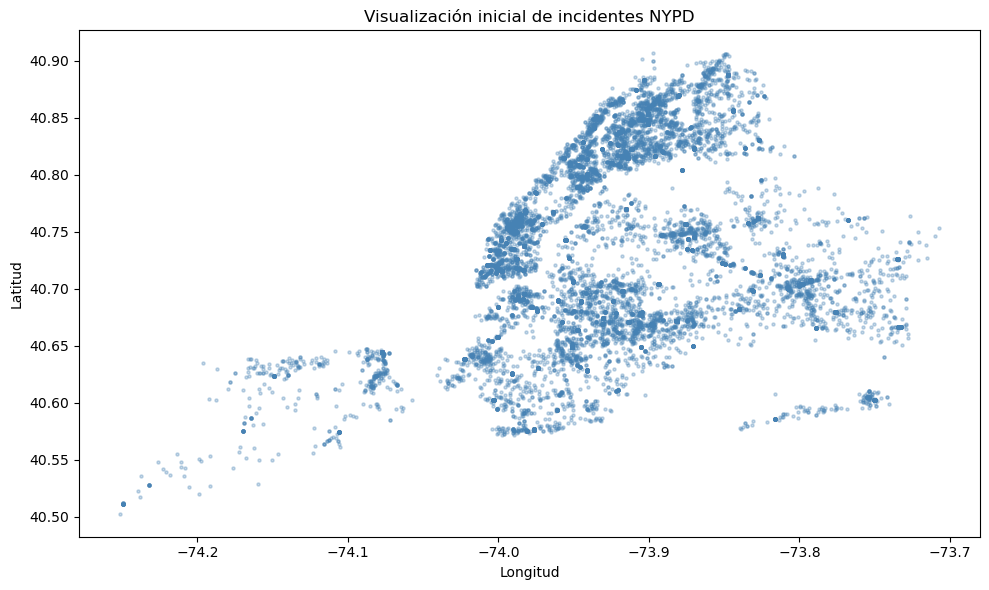

In [46]:
# Dibuja un scatter plot con:
# eje X -> Tu elección
# eje Y -> Tu elección
# tamaño pequeño de punto y cierta transparencia

# Dibuja un scatter plot con:
# eje X -> Tu elección
# eje Y -> Tu elección
# tamaño pequeño de punto y cierta transparencia

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    muestra["Longitude"],   # eje X -> longitud
    muestra["Latitude"],    # eje Y -> latitud
    s=5,               # tamaño pequeño de punto
    alpha=0.3,         # cierta transparencia
    c="steelblue"
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Visualización inicial de incidentes NYPD")
plt.tight_layout()
plt.show()

## 6. Escalado

In [47]:
# Crea el escalador
# scaler = ...
scaler = StandardScaler()

# Escala la muestra
# X_scaled = ...
X = scaler.fit_transform(muestra)

# Muestra las primeras filas escaladas
print(X[:5])

[[ 0.08763864 -0.97120173]
 [-1.3422267  -0.05596869]
 [ 0.68326835 -0.54090066]
 [ 0.81109195 -0.51423757]
 [-1.60411933  2.21036125]]


## 7. Orientación para elegir eps

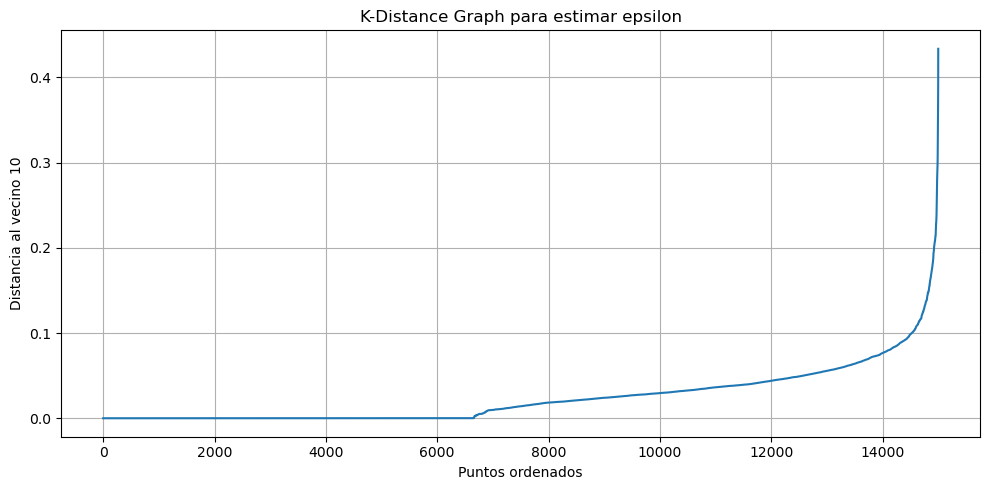

In [48]:
min_samples = 10

# Calcula los vecinos más cercanos
# vecinos = ...
# vecinos.fit(...)
vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos.fit(X)

# Obtén las distancias
# distancias, indices = ...
distancias, indices = vecinos.kneighbors(X)

# Quédate con la distancia al vecino número min_samples
# distancias_ordenadas = ...
distancias_ordenadas = np.sort(distancias[:, -1])

# Ordénalas y represéntalas
plt.figure(figsize=(10, 5))
plt.plot(distancias_ordenadas)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al vecino {min_samples}")
plt.title("K-Distance Graph para estimar epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Aplicación de DBSCAN

In [49]:
# Crea el modelo DBSCAN con un eps inicial razonable (no olvides justificar)
# modelo = ...
modelo = DBSCAN(eps=0.3, min_samples=10).fit(X)

# Entrena el modelo y obtén las etiquetas
# clusters = ...
clusters = modelo.labels_

# Añade la columna cluster a la muestra
muestra["cluster"] = clusters


In [51]:
muestra.head(100)

,Latitude,Longitude,cluster
119217,40.742664,-73.998049,0
232368,40.625823,-73.927612,0
241747,40.791335,-73.964933,0
45312,40.801780,-73.962881,0
196691,40.604423,-73.753195,1
...,...,...,...
62231,40.826283,-73.920707,0
233524,40.710262,-73.951744,0
64198,40.753533,-73.994537,0
242268,40.814270,-73.915341,0


In [54]:
# Calcula:
# - número de clusters (sin contar el ruido)
# - número de puntos ruido
# - tamaño de cada etiqueta

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Número de clusters: {n_clusters}")

n_ruido = np.sum(clusters == -1)
print(f"Número de puntos ruido: {n_ruido}")

print("\nTamaño de cada cluster:")
etiquetas, conteos = np.unique(clusters, return_counts=True)
for etiqueta, conteo in zip(etiquetas, conteos):
    nombre = "Ruido" if etiqueta == -1 else f"Cluster {etiqueta}"
    print(f"  {nombre}: {conteo} puntos")

Número de clusters: 3
Número de puntos ruido: 0

Tamaño de cada cluster:
  Cluster 0: 14176 puntos
  Cluster 1: 195 puntos
  Cluster 2: 629 puntos


## 9. Visualización final

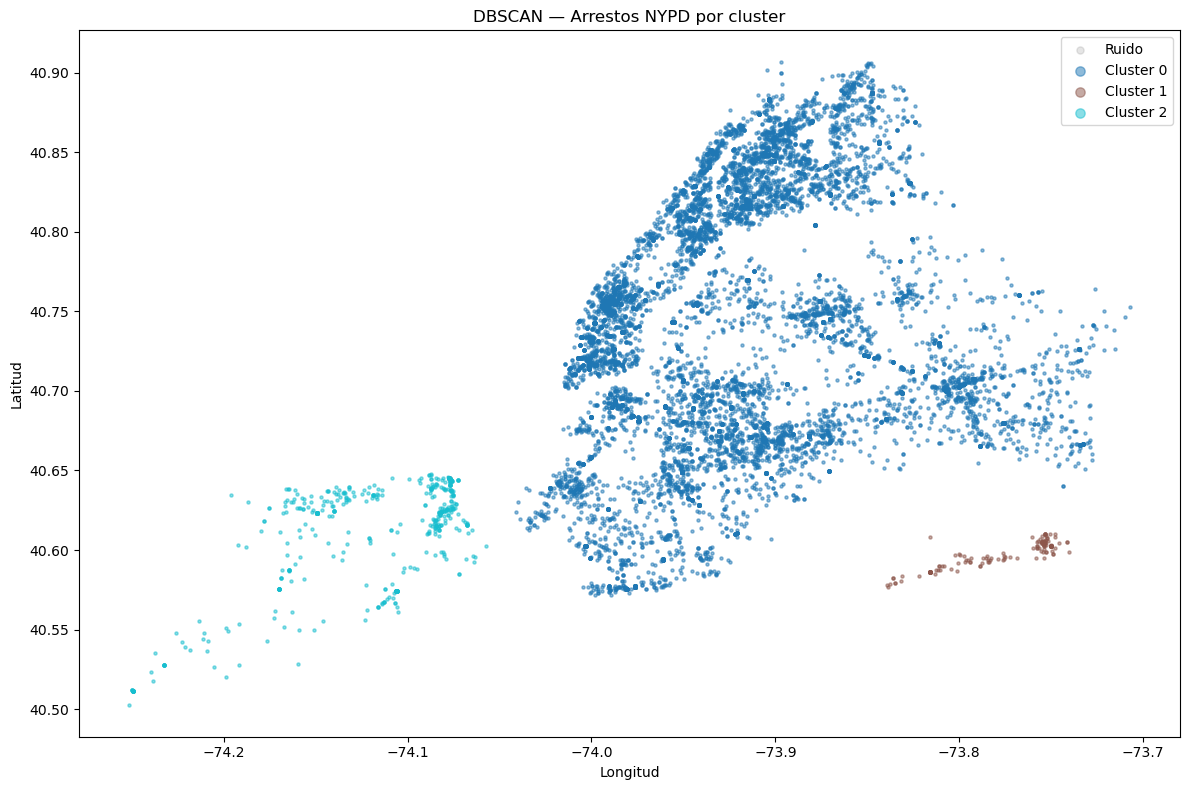

In [55]:
# Representa los puntos preferentemente en distinto color según el cluster encontrado
plt.figure(figsize=(12, 8))

# Paleta de colores: ruido en gris, clusters en colores distintos
colores = plt.cm.tab10(np.linspace(0, 1, n_clusters))

# Dibuja primero el ruido (etiqueta -1) para que quede detrás
ruido = muestra[muestra["cluster"] == -1]
plt.scatter(
    ruido["Longitude"],
    ruido["Latitude"],
    s=3,
    alpha=0.2,
    color="grey",
    label="Ruido"
)

# Dibuja cada cluster con un color distinto
for i, color in zip(range(n_clusters), colores):
    cluster_i = muestra[muestra["cluster"] == i]
    plt.scatter(
        cluster_i["Longitude"],
        cluster_i["Latitude"],
        s=5,
        alpha=0.5,
        color=color,
        label=f"Cluster {i}"
    )

plt.title("DBSCAN — Arrestos NYPD por cluster")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 10. Interpretación

Responde brevemente:

1. ¿Qué significa la etiqueta `-1`?
    -   La etiqueta "-1" significa cada valor o elemento de la muestra al que no se la ha asignado dentro de un cluster.

2. ¿Por qué DBSCAN puede detectar ruido y K-Means no?
    -   DBSCAN puede detectar ruido ya que no asigna obligatoriamente cada elemento a un cluster, en cambio K-Means asigna cada elemento
        al centroide mas cercano de cada cluster, dando lugar a que cada elemento este dentro de un cluster.

3. ¿Qué pasa si `eps` es demasiado pequeño?
    -   Si "eps" es demasido pequeño, la distancia al centro es mas alta, todos esos puntos se consideran como ruido, 
        al no poder agruparlos a un centro por su distancia.

4. ¿Qué pasa si `eps` es demasiado grande?
    -   Si "eps" es demadiado grande, ocurre lo contrario que si fuese pequeño, elementos que podemos considerar como ruido
        los agrupa dentro de un cluster.

5. ¿Por qué este dataset es más adecuado para DBSCAN que otros más simples?
    -   Es mas adecuado ya que DBSCAN es 



## 11. Opcional

Prueba una de estas ampliaciones:
- Compara con K-Means.
- Usa una muestra más grande.
- Analiza sólo un tipo de delito.

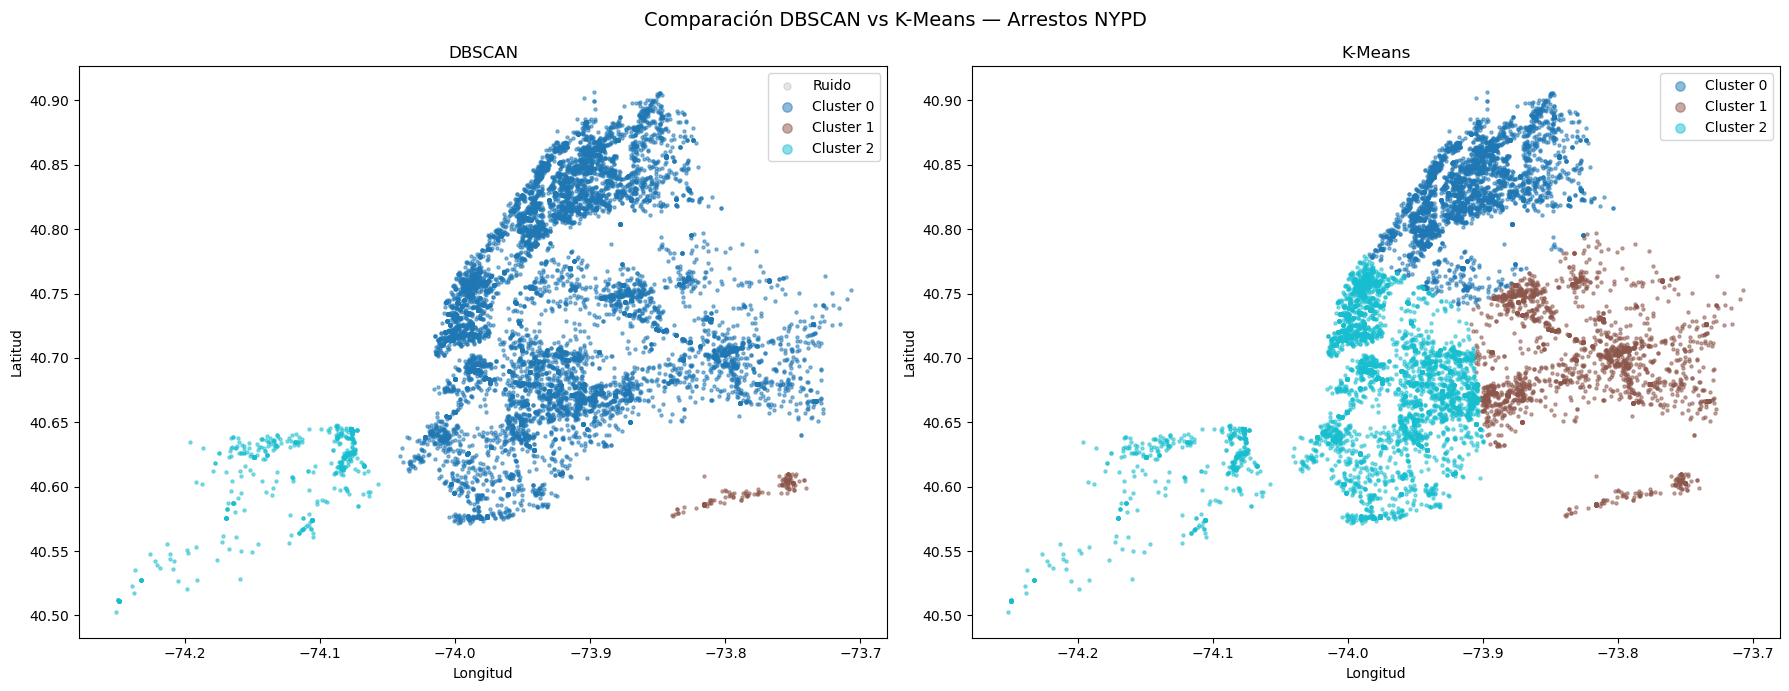

In [58]:
from sklearn.cluster import KMeans

# Usamos el mismo número de clusters que encontró DBSCAN
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X)
muestra["cluster_kmeans"] = kmeans.labels_

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- DBSCAN ---
ax = axes[0]
ruido = muestra[muestra["cluster"] == -1]
ax.scatter(ruido["Longitude"], ruido["Latitude"], s=3, alpha=0.2, color="grey", label="Ruido")
colores = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for i, color in zip(range(n_clusters), colores):
    c = muestra[muestra["cluster"] == i]
    ax.scatter(c["Longitude"], c["Latitude"], s=5, alpha=0.5, color=color, label=f"Cluster {i}")
ax.set_title("DBSCAN")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(markerscale=3)

# --- K-Means ---
ax = axes[1]
for i, color in zip(range(n_clusters), colores):
    c = muestra[muestra["cluster_kmeans"] == i]
    ax.scatter(c["Longitude"], c["Latitude"], s=5, alpha=0.5, color=color, label=f"Cluster {i}")
ax.set_title("K-Means")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(markerscale=3)

plt.suptitle("Comparación DBSCAN vs K-Means — Arrestos NYPD", fontsize=14)
plt.tight_layout()
plt.show()

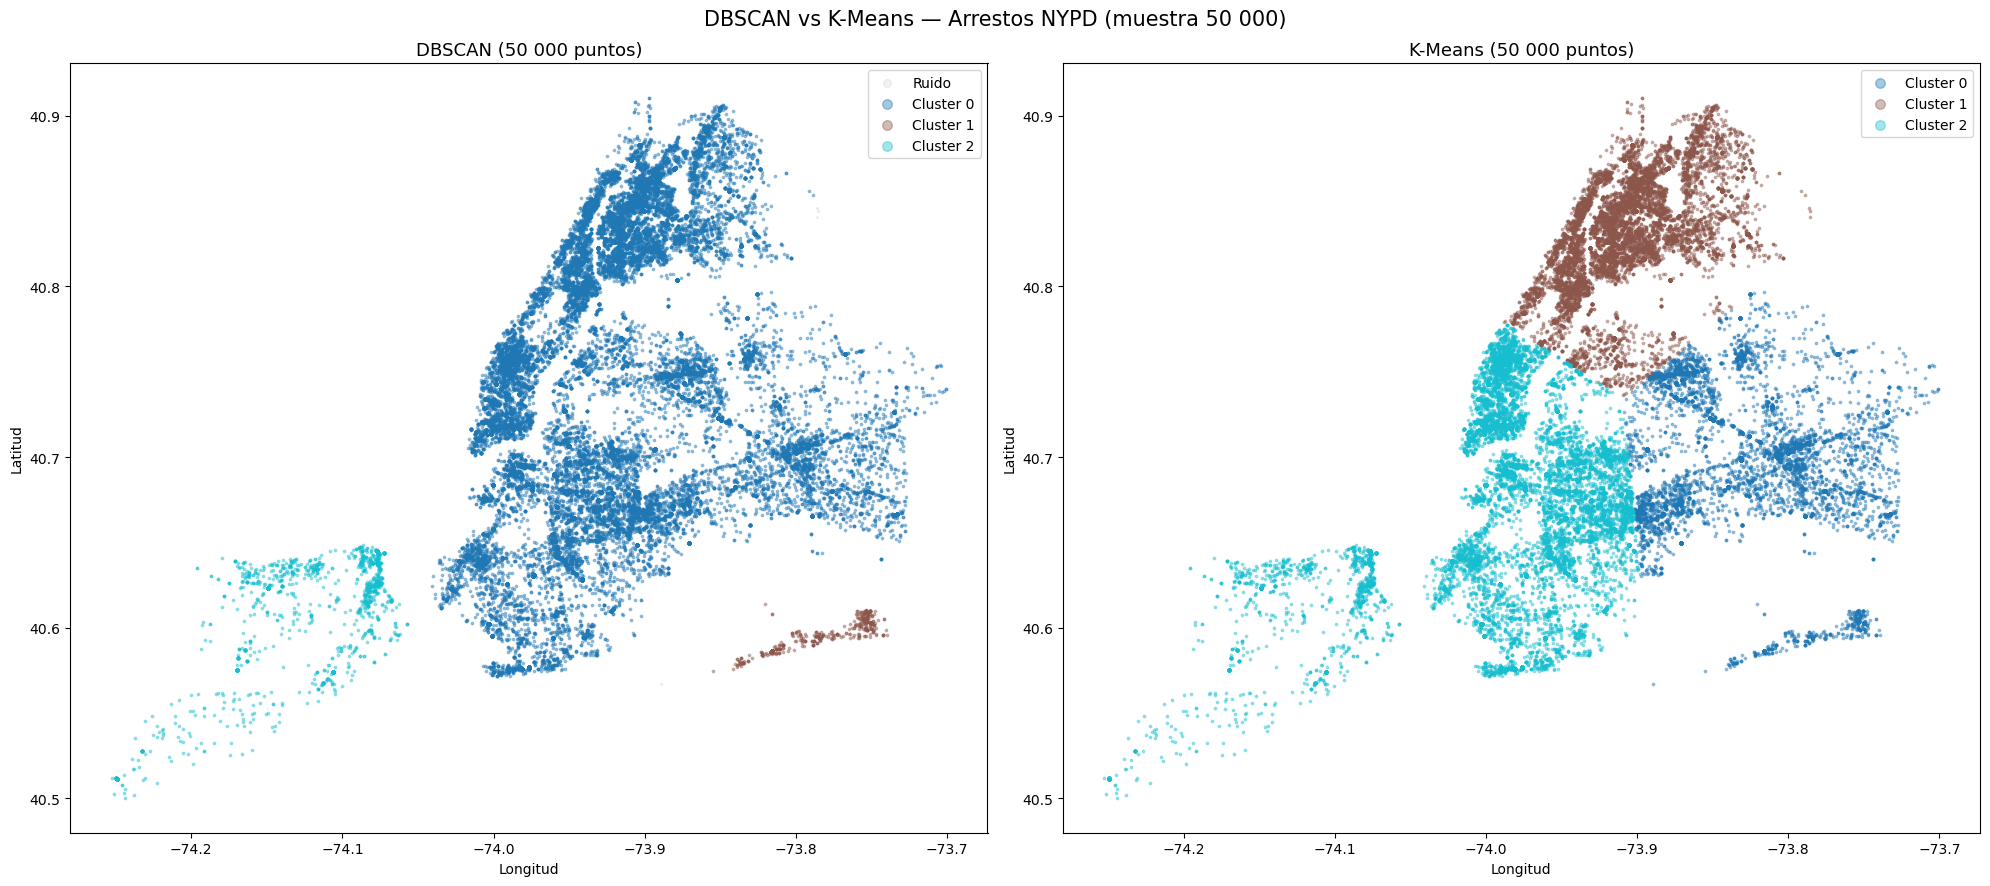

In [62]:
# --- Muestra grande ---
muestra_grande = datos.sample(n=50000, random_state=42)
X_grande = scaler.fit_transform(muestra_grande)

# --- DBSCAN ---
modelo_dbscan = DBSCAN(eps=0.3, min_samples=10).fit(X_grande)
muestra_grande = muestra_grande.copy()
muestra_grande["cluster_dbscan"] = modelo_dbscan.labels_

n_clusters = len(set(modelo_dbscan.labels_)) - (1 if -1 in modelo_dbscan.labels_ else 0)
n_ruido    = np.sum(modelo_dbscan.labels_ == -1)

# --- K-Means (mismo nº de clusters que DBSCAN) ---
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_grande)
muestra_grande["cluster_kmeans"] = kmeans.labels_

# --- Visualización comparativa ---
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
colores = plt.cm.tab10(np.linspace(0, 1, n_clusters))

# --- DBSCAN ---
ax = axes[0]
ruido = muestra_grande[muestra_grande["cluster_dbscan"] == -1]
ax.scatter(ruido["Longitude"], ruido["Latitude"],
           s=2, alpha=0.1, color="grey", label="Ruido")
for i, color in zip(range(n_clusters), colores):
    c = muestra_grande[muestra_grande["cluster_dbscan"] == i]
    ax.scatter(c["Longitude"], c["Latitude"],
               s=3, alpha=0.4, color=color, label=f"Cluster {i}")
ax.set_title("DBSCAN (50 000 puntos)", fontsize=13)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(markerscale=4)

# --- K-Means ---
ax = axes[1]
for i, color in zip(range(n_clusters), colores):
    c = muestra_grande[muestra_grande["cluster_kmeans"] == i]
    ax.scatter(c["Longitude"], c["Latitude"],
               s=3, alpha=0.4, color=color, label=f"Cluster {i}")
ax.set_title("K-Means (50 000 puntos)", fontsize=13)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(markerscale=4)

plt.suptitle("DBSCAN vs K-Means — Arrestos NYPD (muestra 50 000)", fontsize=15)
plt.tight_layout()
plt.show()
